## Step 2: Data Collection

### Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Step 3: Data Understanding

### perform initial investigation

In [ ]:
insurance_data.shape

(1338, 7)

In [ ]:
insurance_data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
insurance_data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Assumption Test

### Test 1: Linearity Test

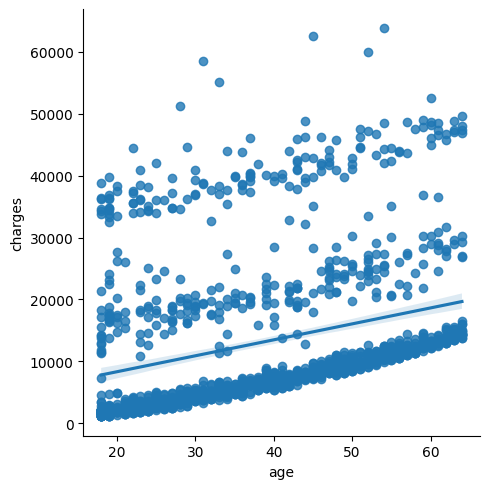

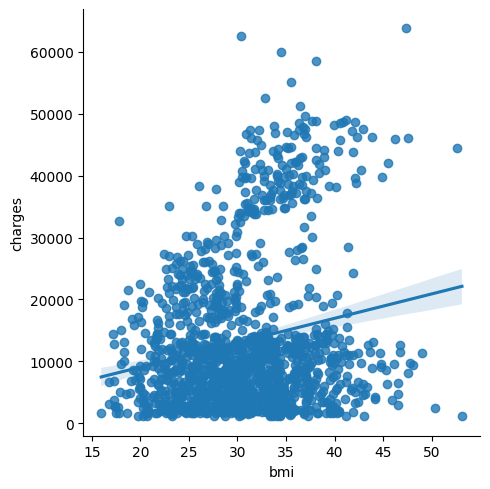

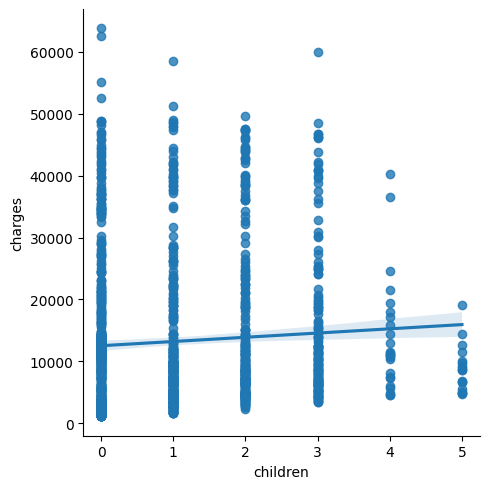

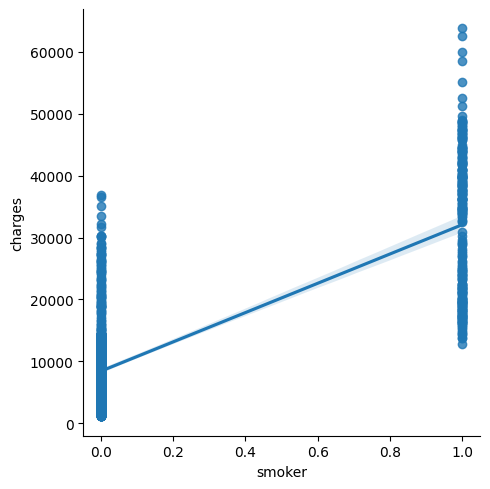

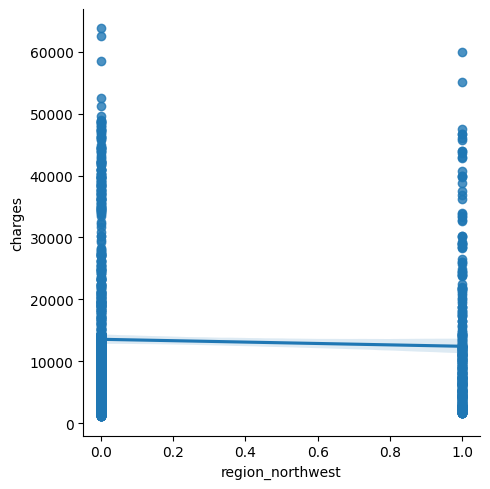

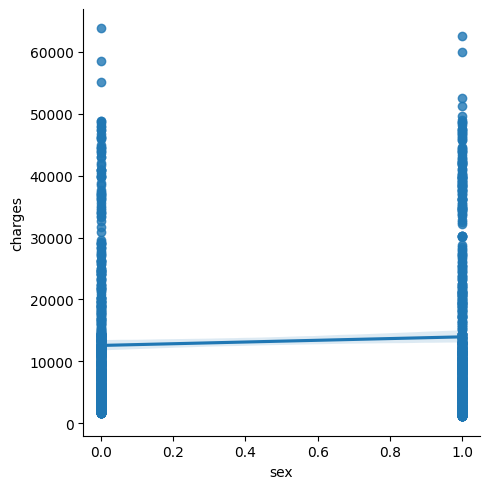

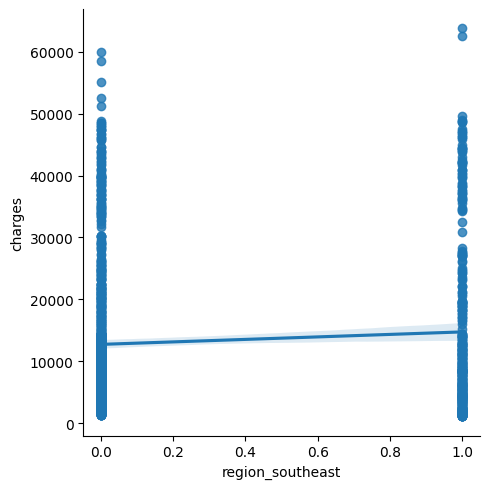

In [ ]:
sns.lmplot(data=insurance_data,x="age",y="charges")
sns.lmplot(data =insurance_data,x="bmi",y="charges")
sns.lmplot(data=insurance_data,x="children",y="charges")
sns.lmplot(data=insurance_data,x="smoker",y="charges")
sns.lmplot(data=insurance_data,x='region_northwest',y="charges")
sns.lmplot(data=insurance_data,x="sex",y="charges")
sns.lmplot(data=insurance_data,x="region_southeast",y="charges")
plt.show()


<Axes: xlabel='smoker', ylabel='charges'>

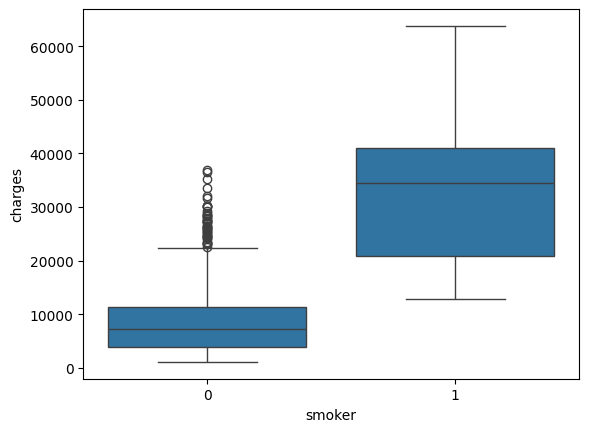

### Step 2: Normality Test

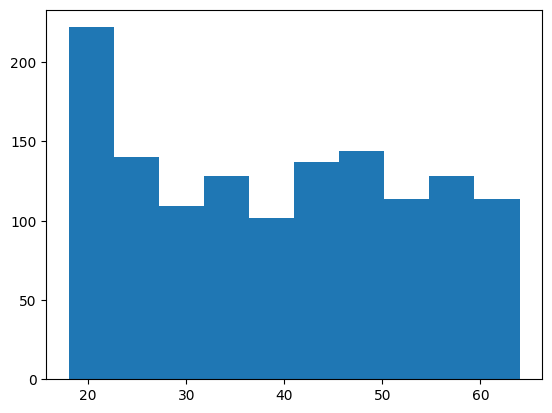

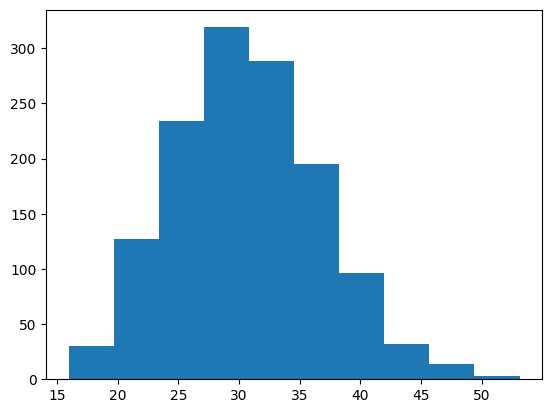

In [ ]:
plt.hist(x=insurance_data["age"])
plt.show()
plt.hist(x=insurance_data["bmi"])
plt.show()


### Test 2: Normality Test is partially passed


### Test 3: Multi Collinearity Test

In [ ]:
corr_matrix = insurance_data.corr()
corr_matrix

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008,-0.000407,-0.011642,0.010016
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292,-0.011156,0.017117,-0.004184
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341,-0.135996,0.270025,-0.006205
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998,0.024806,-0.023066,0.021914
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251,-0.036945,0.068498,-0.036945
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000,-0.039905,0.073982,-0.043210
region_northwest,-0.000407,-0.011156,-0.135996,0.024806,-0.036945,-0.039905,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,0.017117,0.270025,-0.023066,0.068498,0.073982,-0.346265,1.000000,-0.346265
region_southwest,0.010016,-0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320829,-0.346265,1.000000


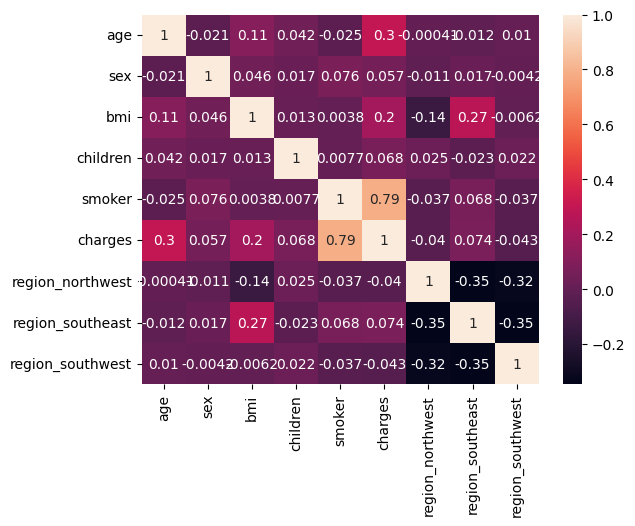

In [ ]:
sns.heatmap(data=corr_matrix,annot=True)
plt.show()

### Test 3: Multi Collinearity Test Passed

### As there are no input parmaters associated with time based features, Test 4: Auto Regression test passed

## Step 4: Data Preparation

In [ ]:
insurance_data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Label Encoding to convert categories to numeric for sex and smoke feature

In [ ]:
insurance_data['sex'] = insurance_data['sex'].map(
    {
        'female':0,
        'male': 1
    }
)

In [ ]:
insurance_data['smoker'] = insurance_data['smoker'].map(
    {
    'no':0,
    'yes':1
    }
  )

### one hot encoding for 3 or more categories data in column, so here we apply it for region

In [ ]:
insurance_data = pd.get_dummies(
    insurance_data,
    columns = ["region"],
    drop_first = True
)


In [ ]:
insurance_data = insurance_data.astype({
    'region_northwest':int,
    'region_southeast':int,
    'region_southwest':int
  }
)

In [ ]:
insurance_data

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


### Separation input and outputs

In [ ]:
X = insurance_data.drop(labels=["charges"],axis=1)

y = insurance_data[['charges']]
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


## Step 5: Model Building

In [ ]:
linear_model = LinearRegression()

## Step 6: Model Training

In [ ]:
linear_model.fit(X,y)

LinearRegression()

In [ ]:
linear_model.intercept_

array([-11938.53857617])

In [ ]:
linear_model.coef_

array([[  256.85635254,  -131.3143594 ,   339.19345361,   475.50054515,
        23848.53454191,  -352.96389942, -1035.02204939,  -960.0509913 ]])

## Step 6: Model Testing

In [ ]:
y_pred = linear_model.predict(X)

In [ ]:
insurance_data

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,predicted output
0,19,0,27.900,0,1,16884.92400,0,0,1,25293.713028
1,18,1,33.770,1,0,1725.55230,0,1,0,3448.602834
2,28,1,33.000,3,0,4449.46200,0,1,0,6706.988491
3,33,1,22.705,0,0,21984.47061,1,0,0,3754.830163
4,32,1,28.880,0,0,3866.85520,1,0,0,5592.493386
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0,12351.323686
1334,18,0,31.920,0,0,2205.98080,0,0,0,3511.930809
1335,18,0,36.850,0,0,1629.83350,0,1,0,4149.132486
1336,21,0,25.800,0,0,2007.94500,0,0,1,1246.584939


## Step 8: Model Evaluation

In [ ]:
error = y - y_pred
error

,charges
0,-8408.789028
1,-1723.050534
2,-2257.526491
3,18229.640447
4,-1725.638186
...,...
1333,-1750.775386
1334,-1305.950009
1335,-2519.298986
1336,761.360061


### Test 5: Homoscadesticity Test

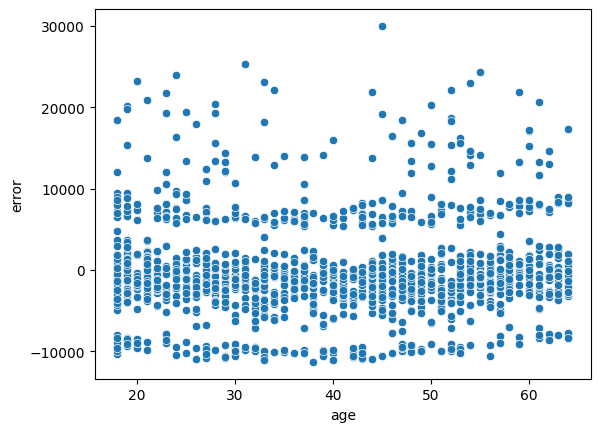

In [ ]:
sns.scatterplot(data=insurance_data,x='age',y= error.squeeze())
plt.xlabel("age")
plt.ylabel("error")
plt.show()


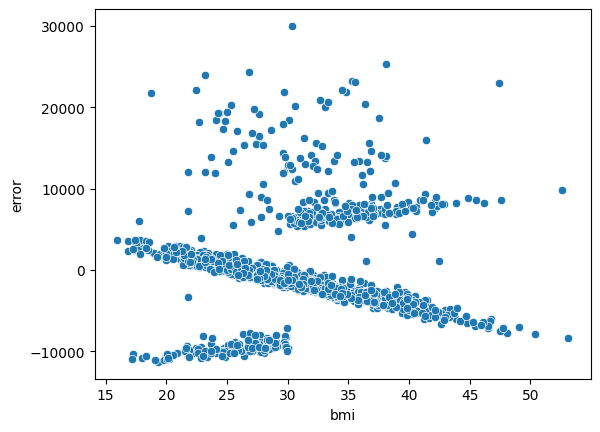

In [ ]:
sns.scatterplot(data=insurance_data,x="bmi",y=error.squeeze())
plt.xlabel("bmi")
plt.ylabel("error")
plt.show()

### Test 5 Homoscadesticity test failed

### Test 6 Zero Residual mean

<Axes: xlabel='charges'>

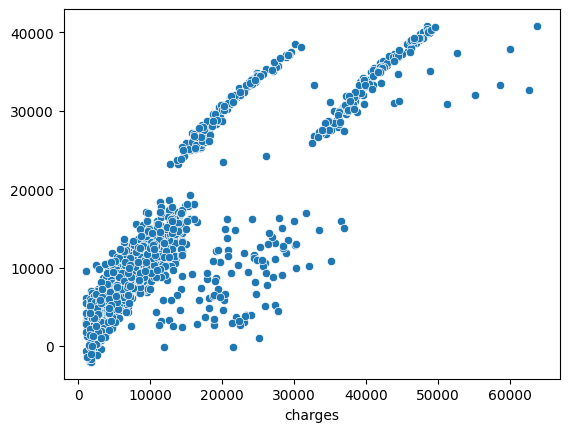

In [ ]:
sns.scatterplot(x=insurance_data["charges"],y= y_pred.squeeze())


### Test 6: Zero Residual Mean test failed

##Step 9: Model Deployment

In [ ]:
from pickle import dump

In [ ]:
dump(linear_model,open("insurance.pkl","wb"))

In [ ]:
from pickle import load

In [ ]:
insurance_intel = load(file=open("insurance.pkl",mode='rb'))

In [ ]:
insurance_intel.predict(X)


array([[25293.7130284 ],
       [ 3448.60283431],
       [ 6706.9884907 ],
       ...,
       [ 4149.13248568],
       [ 1246.58493898],
       [37085.62326757]])